In [1]:
!git clone https://github.com/Mikayla-ds2/surge-sense.git

Cloning into 'surge-sense'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 137 (delta 64), reused 94 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 5.48 MiB | 29.55 MiB/s, done.
Resolving deltas: 100% (64/64), done.


In [2]:
# dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/cleaned-data.csv')

data = data.drop(['Unnamed: 0'], axis=1)

data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,admission_flag,department_referral,age_category,time_category,day_of_week
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,False,No referral.,Senior,Day,Wednesday
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,True,No referral.,Minor,Day,Saturday
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,True,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,True,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,False,Orthopedics,Minor,Evening,Tuesday


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           9216 non-null   object
 1   patient_gender       9216 non-null   object
 2   patient_race         9216 non-null   object
 3   patient_age          9216 non-null   int64 
 4   admission_day        9216 non-null   object
 5   admission_time       9216 non-null   object
 6   patient_waittime     9216 non-null   int64 
 7   admission_flag       9216 non-null   bool  
 8   department_referral  9216 non-null   object
 9   age_category         9216 non-null   object
 10  time_category        9216 non-null   object
 11  day_of_week          9216 non-null   object
dtypes: bool(1), int64(2), object(9)
memory usage: 801.1+ KB


In [6]:
data.describe()

,patient_age,patient_waittime
count,9216.000000,9216.000000
mean,39.855143,35.259874
std,22.755125,14.735323
min,1.000000,10.000000
25%,20.000000,23.000000
50%,39.000000,35.000000
75%,60.000000,48.000000
max,79.000000,60.000000


In [7]:
data.isnull().sum()

,0
patient_id,0
patient_gender,0
patient_race,0
patient_age,0
admission_day,0
admission_time,0
patient_waittime,0
admission_flag,0
department_referral,0
age_category,0


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.shape

(9216, 12)

In [10]:
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

In [11]:
# for all my plots
palette = ['#EAD3A9','#C4B389','#B7966A',
            '#9D9368','#A05135','#84592B',
            '#733F28','#743015','#462D1B']
discrete = ListedColormap(palette)
continuous = LinearSegmentedColormap.from_list('earth_sequential', palette)

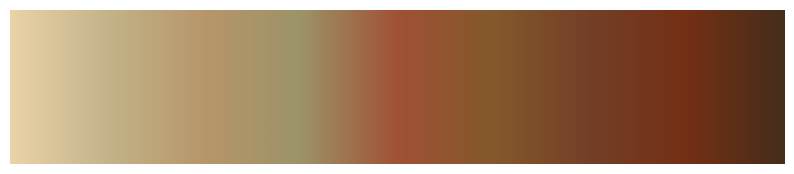

In [12]:
gradient = np.linspace(0, 1, 512)[None, :]
plt.figure(figsize=(10, 2))
plt.imshow(
    gradient,
    aspect='auto',
    cmap=continuous
)
plt.axis('off')
plt.show()

<Figure size 1200x700 with 0 Axes>

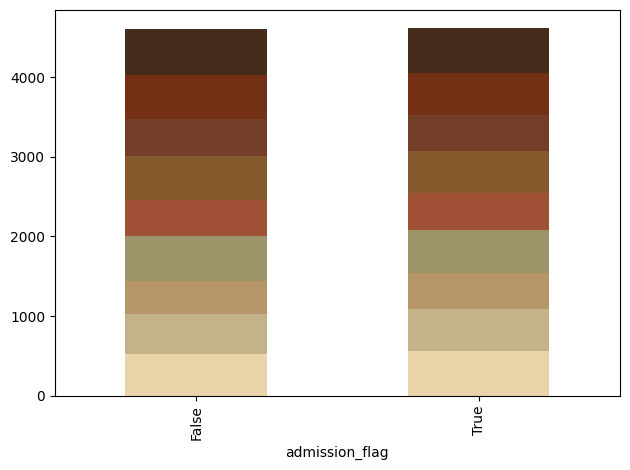

In [13]:
# creating cross table to evaluate if admission is a valuable variable
crosstab01 = pd.crosstab(data['admission_flag'],
                         data['patient_waittime'])

plt.figure(figsize=(12, 7))
crosstab01.plot(kind='bar', stacked=True, colormap=discrete, legend=False)
plt.tight_layout()
plt.show()

In [14]:
# determined by the previous images, admission_flag
# has inconclusive context and
# thus need to be excluded from any further analysis or modeling.
data = data.drop(['admission_flag'], axis=1)
data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,department_referral,age_category,time_category,day_of_week
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,No referral.,Senior,Day,Wednesday
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,No referral.,Minor,Day,Saturday
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,Orthopedics,Minor,Evening,Tuesday


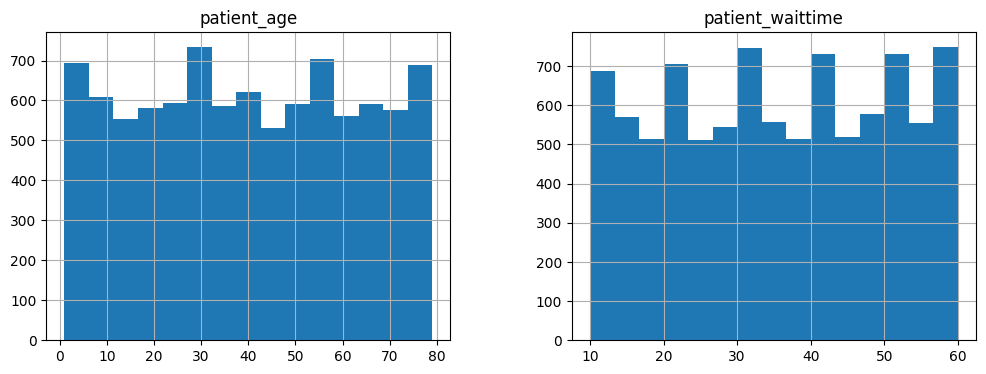

In [15]:
histogram = data.select_dtypes(
    include=['number', 'bool']).hist(bins=15, figsize=[12, 4])
plt.show()

In [16]:
%cd surge-sense
from deviation import test_deviation
#from plot_deviation import plot_diverging_plot, plot_confidence_heatmap

/content/surge-sense


In [17]:
%pip install "pywaffle[icons]" 
from pywaffle import Waffle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 50.6 MB/s eta 0:00:00:00:0100:01


In [18]:
deviation_data = data[data['department_referral'] != 'No referral.']
deviation_data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,department_referral,age_category,time_category,day_of_week
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,Orthopedics,Minor,Evening,Tuesday
10,497-14-6812,Female,White,73,2024-07-26,01:45:00,34,Gastroenterology,Senior,Night,Friday
11,393-38-9502,Female,White,16,2024-10-03,22:02:00,39,Orthopedics,Minor,Evening,Thursday


In [19]:
result = test_deviation(
    data=deviation_data,
    feature='department_referral',
    outcome='day_of_week'
)
result.tidy

,department_referral,day_of_week,observed_count,expected_count,pct,diff_pp,adjusted_residual,baseline_pct,low_reliability,significant
0,Cardiology,Friday,37,32.754717,14.919355,1.711808,0.823418,13.207547,False,False
1,Cardiology,Monday,30,37.628931,12.096774,-3.076182,-1.396456,15.172956,False,False
2,Cardiology,Saturday,38,36.719078,15.322581,0.516501,0.236845,14.806080,False,False
3,Cardiology,Sunday,31,33.404612,12.500000,-0.969602,-0.462540,13.469602,False,False
4,Cardiology,Thursday,38,34.509434,15.322581,1.407486,0.662301,13.915094,False,False
5,Cardiology,Tuesday,39,36.654088,15.725806,0.945932,0.434081,14.779874,False,False
6,Cardiology,Wednesday,35,36.329140,14.112903,-0.535944,-0.246848,14.648847,False,False
7,Gastroenterology,Friday,20,23.509434,11.235955,-1.971592,-0.795697,13.207547,False,False
8,Gastroenterology,Monday,35,27.007862,19.662921,4.489965,1.710108,15.172956,False,False
9,Gastroenterology,Saturday,26,26.354822,14.606742,-0.199338,-0.076692,14.806080,False,False


In [20]:
result.summary()

,Deviation test
Chi-squared statistic,42.397931
p-value,0.214462
Degrees of Freedom,36.000000
Number of cells,49.000000
Bonferroni alpha,0.001020
Critical z-score,3.284839


In [21]:
result.table

day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
department_referral,,,,,,,
Cardiology,14.919355,12.096774,15.322581,12.500000,15.322581,15.725806,14.112903
Gastroenterology,11.235955,19.662921,14.606742,13.483146,16.292135,12.921348,11.797753
General Practice,12.554348,15.108696,15.543478,12.880435,13.804348,15.271739,14.836957
Neurology,19.170984,12.953368,13.471503,12.953368,13.471503,15.025907,12.953368
Orthopedics,13.366834,14.773869,14.472362,15.376884,14.673367,12.864322,14.472362
Physiotherapy,14.492754,17.391304,13.405797,11.956522,11.231884,14.855072,16.666667
Renal,6.976744,18.604651,9.302326,12.790698,8.139535,26.744186,17.441860


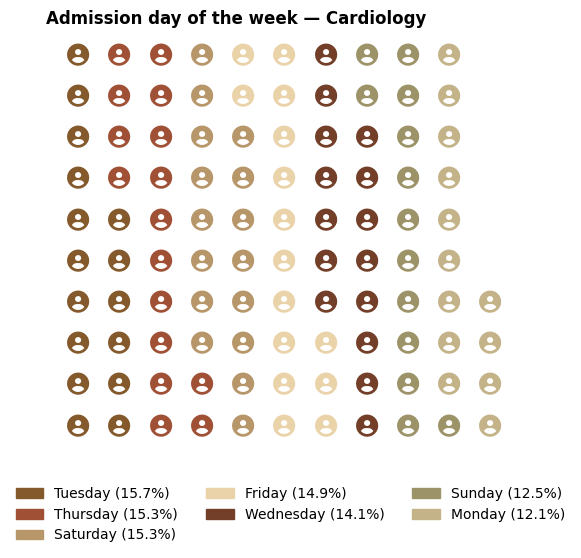

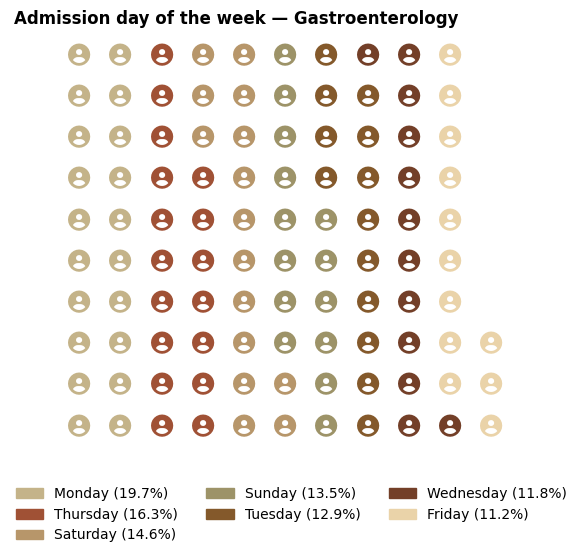

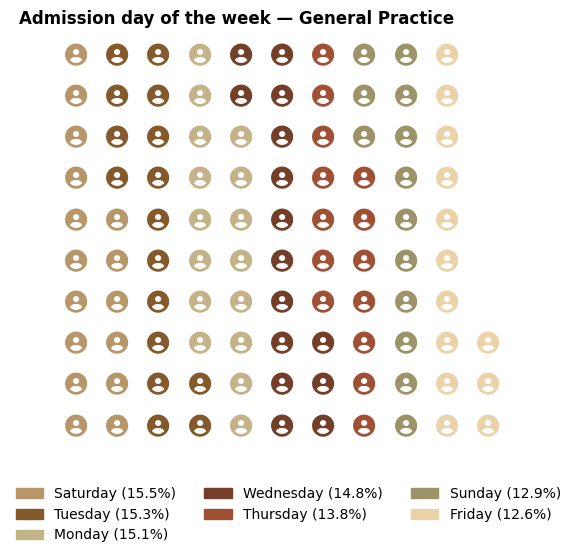

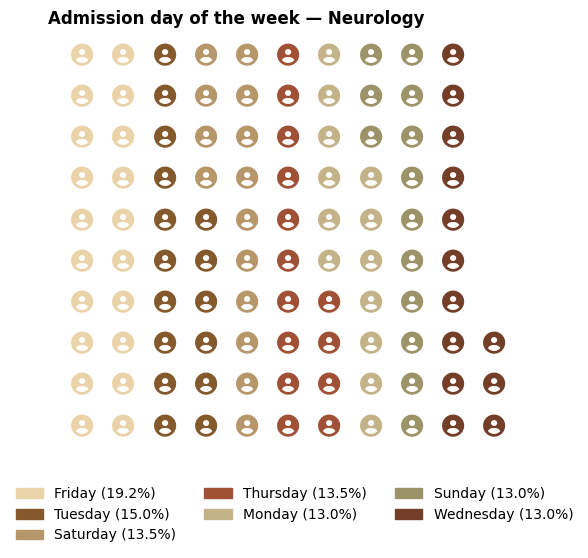

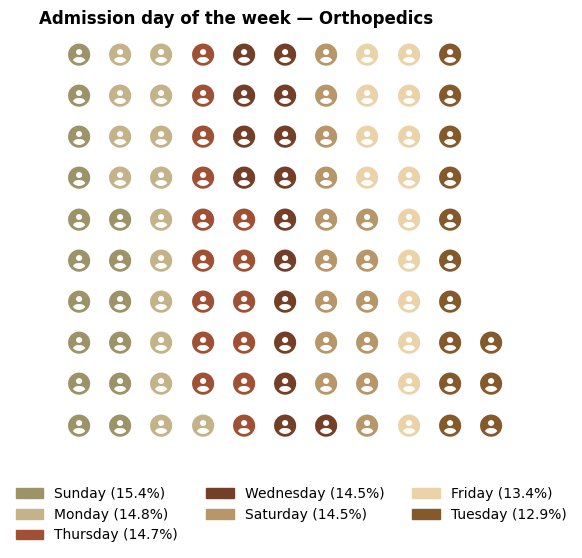

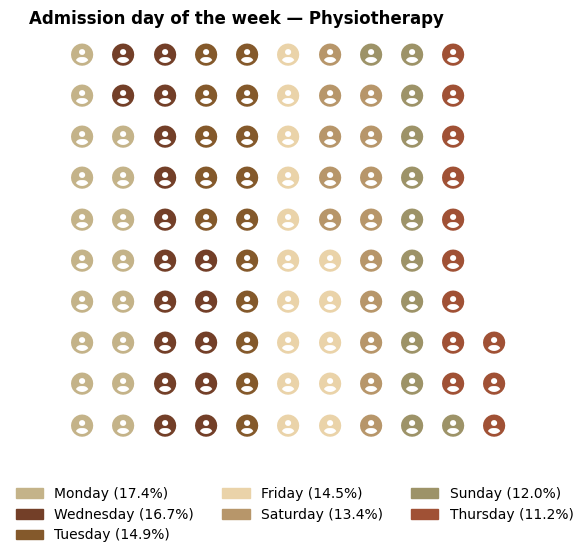

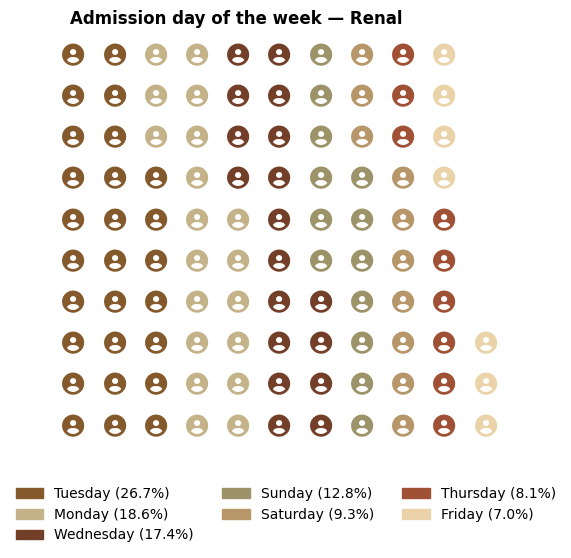

In [25]:
plot_data = result.table  # days as rows (index), departments as columns, each row ~100%

departments = plot_data.index.tolist()
days = plot_data.columns.tolist()

# One fixed color per day, defined ONCE, so the same day reads as the
# same color in every department's panel. This is the fix for the
# "same day, different color per subplot" problem in the original --
# without this dict, pywaffle's default color cycle restarts fresh
# for each subplot's own category list.
# Use the notebook's existing discrete palette in the same order as the
# actual day columns in `plot_data`; no hard-coded hex map needed.
day_color_map = {
    day: color
    for day, color in zip(days, discrete.colors[:len(days)])
}
# Reorder to match plot_data's actual column order, in case your
# crosstab's columns aren't in Mon-Sun order.
day_color_map = {day: day_color_map[day] for day in days}

for dept in departments:
    series = plot_data.loc[dept]
 
    # Single-waffle form: values/labels/colors/icons go directly as
    # top-level arguments, no 'plots={}' dict needed -- that dict was
    # only for packing multiple waffles into one shared figure.
    sorted_series = series.sort_values(ascending=False)
    sorted_days = sorted_series.index.tolist()

    fig = plt.figure(
        FigureClass=Waffle,
        values=sorted_series,
        colors=[day_color_map[day] for day in sorted_days],
        labels=[f"{day} ({pct:.1f}%)" for day, pct in sorted_series.items()],
        icons="circle-user",
        icon_size=16,
        rows=10,
        rounding_rule="ceil",
        legend={
            "loc": "lower center",
            "bbox_to_anchor": (0.5, -0.3),
            "ncol": 3,
            "framealpha": 0,
        },
        figsize=(7, 6),
    )
    fig.suptitle(
        f"Admission day of the week — {dept}",
        fontweight="bold",
        x=0.3,
        y=0.95,
        ha="center",
    )
     
plt.tight_layout()
plt.show()

In [26]:
result.tidy.diff_pp

,diff_pp
0,1.711808
1,-3.076182
2,0.516501
3,-0.969602
4,1.407486
5,0.945932
6,-0.535944
7,-1.971592
8,4.489965
9,-0.199338


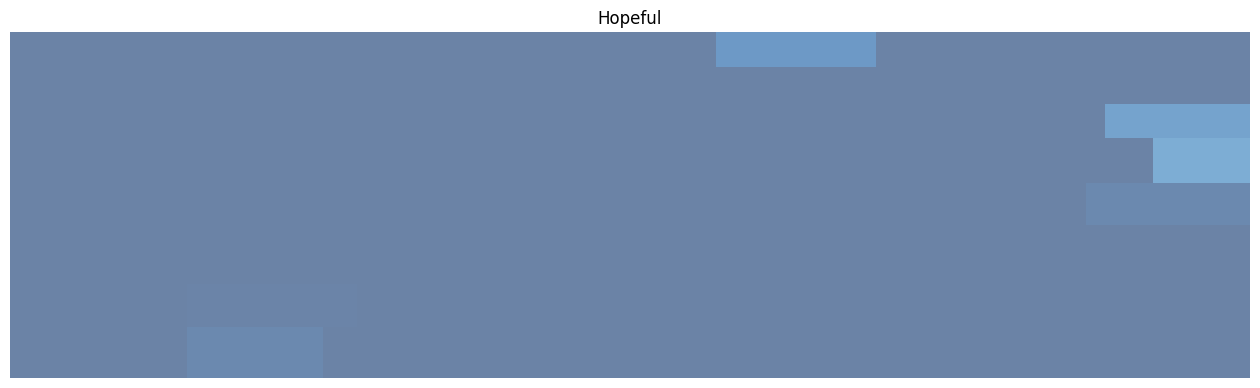

In [ ]:
# hopefully this works for treemap
%pip install squarify 
%pip install matplotlib
import matplotlib
import squarify
from plot_deviation import _confidence_alpha  # reuse, don't duplicate

above_color = "#9D9368"
below_color = "#743015"

colors = []
for row in result.tidy.itertuples():
    base_color = above_color if row.diff_pp >= 0 else below_color
    alpha = _confidence_alpha(
        row.adjusted_residual, row.significant, row.low_reliability, result.z_critical
    )
    rgba = matplotlib.colors.to_rgba(base_color, alpha=alpha)
    colors.append(rgba)

fig = plt.gcf()
fig.set_size_inches(16, 4.5)

squarify.plot(
    sizes=result.tidy["rate_pct"],       # or composition_pct, whichever your table has
    label=result.tidy["<outcome column>"],
    color=colors,
)
plt.axis("off")
plt.show()

In [ ]:
fig1 = plot_diverging_plot(result=result, feature='day_of_week', outcome=
                           'department_referral')
fig2 = plot_confidence_heatmap(result, feature='day_of_week', outcome=
                               'department_referral')
plt.show()

In [ ]:
from pathlib import Path
features = [
    'patient_race',
    'patient_gender',
    'age_category',
    'time_category',
    'day_of_week'
]

outcome = 'department_referral'
plot_dir = Path('rate_deviation_plots')
plot_dir.mkdir(exist_ok=True)

results = {}
ranking_rows = []


for feature in features:
    result = test_deviation(
        data=data,
        feature=feature,
        outcome=outcome,
        exclude_value='No referral.',
    )
    results[feature] = result
    
    fig = plot_diverging_plot(
        result=result,
        feature=feature,
        outcome=outcome,
    )
    fig.savefig(
        plot_dir / f'{feature}_diverging.png',
        dpi=200,
        bbox_inches='tight',
    )
    plt.close(fig)
    
    fig = plot_confidence_heatmap(
        result=result,
        feature=feature,
        outcome=outcome,
    )
    fig.savefig(
        plot_dir / f'{feature}_confidence_heatmap.png',
        dpi=200,
        bbox_inches='tight',
    )
    plt.close(fig)
    
    ranking_rows.append({
        'feature': feature,
        'chi2_statistic': result.chi2_statistic,
        'p_value': result.chi2_pvalue,
        'degrees_of_freedom': result.dof,
        'significant_cells': 
            result.tidy['significant'].sum(),
        'tested_cells': result.n_cells,
    })
p_value_ranking = (
    pd.DataFrame(ranking_rows)
    .sort_values('p_value', ascending=False)
    .reset_index(drop=True)
)
p_value_ranking

In [ ]:
for feature in features:
    for feature in features:
        result = test_deviation(
            data=data,
            feature=feature,
            outcome=outcome,
        )
        results[feature] = result

        print(f"\n=== Feature: {feature} ===")
        print(result.summary())

In [ ]:
print(data['patient_race'].unique())
print(data['department_referral'].unique())

In [ ]:
data['patient_race'].value_counts(normalize=True)

In [ ]:
# this code allows me to only see the people who were referred to a department
referred = data.loc[data[
    'department_referral'] != 'No referral.', 'department_referral']

In [ ]:
referred.value_counts(normalize=True)

In [ ]:
data['patient_race'].value_counts(
    normalize=True).mul(100).round(1)

In [ ]:
# is referred but adds race for proper percentage calculations
referrals = data.loc[
    data['department_referral'].ne('No referral.'),
    ['patient_race', 'department_referral']
]

# the percentage of patients of that race referred to that department
crosstab_race_dpt = (
    pd.crosstab(
        referrals['patient_race'],
        referrals['department_referral'],
        normalize='columns' # index means to sums to 100 for the row; columns for the column
    )
    .mul(100)
)
# for index: given a patient is of a certain race, what percentage of their referrals go to each department
# for columns: given a pateint was referred to a certain department, what's the racial breakdown of that department
crosstab_race_dpt.round(1)

In [ ]:
referrals['patient_race'].value_counts(
    normalize=True).mul(100).round(1)

In [ ]:
baseline = (
    referrals['department_referral'].value_counts(
        normalize=True).
    mul(100).
    reindex(crosstab_race_dpt.columns)
)

difference_pp = crosstab_race_dpt.sub(
    baseline, axis='columns')
difference_pp.round(2)

In [ ]:
print(baseline)

In [ ]:
referrals_waittime = data.loc[
    data['department_referral'].ne('No referral.'),
    ['patient_waittime', 'department_referral']
]

In [ ]:
mean_values = referrals_waittime.groupby('department_referral')['patient_waittime'].mean()

plt.figure(figsize=(12, 6))
mean_values.plot(kind='bar', color=discrete.colors)
plt.title('Average Waittime per Department Referral')
plt.xlabel('Department Referral')
plt.ylabel('Patient Waittime')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print(data.dtypes)

In [ ]:
data.describe()

In [ ]:
columns = ['patient_race', 'patient_gender', 'age_category', 'day_of_week', 'time_category']
for col in columns:
    mean_values = data.groupby(col)['patient_waittime'].mean()

    plt.figure(figsize=(12, 6))
    mean_values.plot(kind='bar', color=discrete.colors)
    plt.title(f"Average waittime per {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel('Patient Waittime')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
mean_values = data.groupby('patient_race')['patient_age'].mean()

plt.figure(figsize=(12, 6))
mean_values.plot(kind='bar', color=discrete.colors)
plt.title('Average Age per Patient Race')
plt.xlabel('Patient Race')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
%pip install dython 

In [ ]:
data = data.drop(['patient_id'], axis=1)

In [ ]:
from dython.nominal import associations
associations(data, cmap=discrete)

none of the correlations meet all criteria for being confounders so Simpson's paradox is unlikely and thus stratifying isn't necessary.